<table style="background-color: transparent; width:100%">
    <tr style="background-color: transparent; text-align:center;">
        <td width="100%" align="center"><font size="7" color="#6366F1"><b>Computación Cuántica</b></font></td>
    </tr>
    <tr style="background-color: transparent; text-align:center;">
        <td width="100%"><font size="4" color="black">Temas Selectos de Ingeniería en Computación III</font></td>
    </tr>
    <tr style="background-color: transparent; text-align:center;">
        <td width="100%"><font size="4" color="black">Facultad de Ingeniería, UNAM | Semestre: 2027-1</font></td>
    </tr>
    <tr style="background-color: transparent; text-align:center;">
        <td width="100%"><font size="6" color="#6366F1"><b>Práctica 3: Algoritmos Cuánticos I (Teleportación, Codificación Superdensa y Funciones Lógicas)</b></font></td>
    </tr>
</table>

---
* **Alumna:** Karla Beatriz Rojas Chimal
* **No. de Cuenta:** 320048025
* **Carrera:** Ingeniería en Computación
* **Profesora Titular:** Naomi Itzel Reyes Granados
* **Asistente:** González Juárez Sebastián

---
### Contenido del Notebook

1. [Teleportación cuántica](#1)
2. [Codificación superdensa](#2)
3. [Funciones cuánticas AND y OR](#3)
4. [Opcional: Teleportación cuántica con PennyLane](#4)


### Declaración sobre el uso de Inteligencia Artificial (Instrucción C)
De acuerdo con los lineamientos de la práctica, declaro el uso de herramientas de inteligencia artificial en la elaboración de este notebook.

* **Herramienta empleada:** Antigravity (asistente de IA de programación de Google DeepMind).
* **Incisos en los que se utilizó:** Estructura general del notebook, código y redacción de las explicaciones de los Ejercicios 1, 2, 3 y 4.
* **Razón de su uso:** Generar el borrador del notebook siguiendo el formato de las prácticas anteriores y ejecutarlo en el entorno `compu_cuantica` para obtener las salidas. El resultado fue revisado por mí antes de la entrega.
* **Prompt principal utilizado:** *"De la práctica 3 y 4 haz el documento correspondiente de _RojasChimal_KarlaBeatriz_PRACTICAENTREGAR ... guíate de los laboratorios 1 y 2 para el formato ... NO USES AERSIMULATOR ... usa el kernel/ambiente de python de compu_cuantica"* (se anexaron las instrucciones completas de la práctica).


In [1]:
# Instalo todo en silencio, directo en el kernel que estoy usando
%pip install qiskit qiskit-ibm-runtime pennylane matplotlib pylatexenc --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ==============================================================================
#  /\_/\
# ( o.o )   CONFIGURACIÓN INICIAL: LIBRERÍAS
#  > ^ <
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, DensityMatrix, partial_trace, state_fidelity
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeOsaka

# Este es mi simulador "limpio" (sin ruido) y lo voy a usar en toda la práctica
sim = BasicSimulator()
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


<a id="1"></a>
```
 /\_/\
( o.o )  ¡a trabajar!
 > ^ <
```

# 1. Teleportación cuántica

### 1.a) Preparación del estado a teleportar
Se define la función `teleportacion` que recibe los ángulos $(\theta,\phi,\lambda)$ de la compuerta `U` con la que Alicia prepara el estado

$$
|\psi\rangle = U(\theta,\phi,\lambda)|0\rangle=\cos\tfrac{\theta}{2}|0\rangle+e^{i\phi}\sin\tfrac{\theta}{2}|1\rangle .
$$

Asignación de qubits: `q0` contiene $|\psi\rangle$, `q1` es el qubit de Alicia y `q2` el de Bob. El par entrelazado se genera entre `q1` y `q2`.

La función completa (incisos a y b) se define en la siguiente celda; después se muestra únicamente la etapa de preparación del estado.

Circuito de preparación de |psi>:


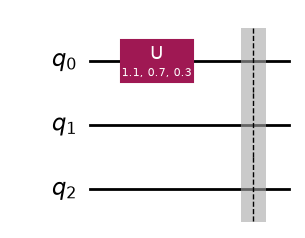

Vector de estado de |psi>: [0.8525+0.j     0.3998+0.3367j]


<IPython.core.display.Latex object>

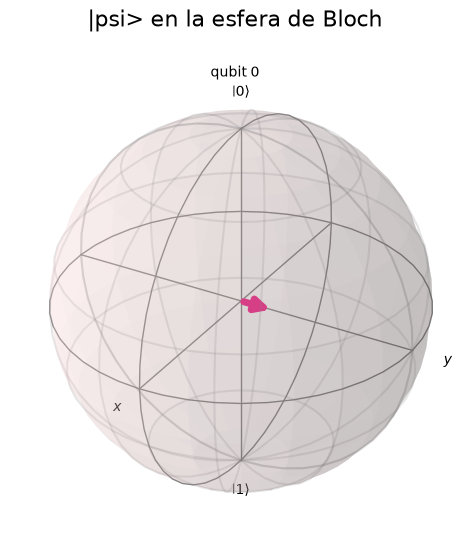

In [3]:
# ==============================================================================
#  /\_/\
# ( o.o )   1. TELEPORTACIÓN CUÁNTICA: FUNCIÓN GENERAL
#  > ^ <
# ==============================================================================

# Mi truco: siempre parto de |Phi+> y le aplico una Pauli a q2 (Bob) para llegar a los otros tres Bell
BELL_PAULIS = {
    "phi+": [],            # |Phi+> = (|00> + |11>)/sqrt(2)
    "phi-": ["z"],         # |Phi-> = (|00> - |11>)/sqrt(2)
    "psi+": ["x"],         # |Psi+> = (|01> + |10>)/sqrt(2)
    "psi-": ["x", "z"],    # |Psi-> = (|01> - |10>)/sqrt(2)  (salvo fase global)
}

def teleportacion(theta, phi, lam, bell="phi+", medir=False, solo_preparacion=False):
    """
    Protocolo de teleportación cuántica para cualquiera de los 4 estados de Bell.

    q0: estado |psi> = U(theta, phi, lam)|0>  (a teleportar)
    q1: qubit de Alicia      q2: qubit de Bob

    bell : 'phi+', 'phi-', 'psi+' o 'psi-'
    medir: si es True agrega un bit clásico y mide únicamente a Bob (q2)
    solo_preparacion: devuelve únicamente el circuito que prepara |psi>
    """
    if bell not in BELL_PAULIS:
        raise ValueError("bell debe ser 'phi+', 'phi-', 'psi+' o 'psi-'")

    qc = QuantumCircuit(3, 1) if medir else QuantumCircuit(3)

    # Etapa 1: dejo listo el |psi> en q0 usando la compuerta U
    qc.u(theta, phi, lam, 0)
    qc.barrier()
    if solo_preparacion:
        return qc

    # Etapa 2: armo el par de Bell que me pidan entre q1 y q2
    qc.h(1)
    qc.cx(1, 2)
    for pauli in BELL_PAULIS[bell]:
        getattr(qc, pauli)(2)
    qc.barrier()

    # Etapa 3: le toca a Alicia (CNOT y Hadamard sobre q0 y q1)
    qc.cx(0, 1)
    qc.h(0)
    qc.barrier()

    # Etapa 4: ahora Bob arregla su qubit.
    #  (i) primero quito la Pauli extra que le puse al Bell (en orden inverso)
    for pauli in reversed(BELL_PAULIS[bell]):
        getattr(qc, pauli)(2)
    #  (ii) luego las correcciones de siempre, pero controladas (medición diferida):
    #       X si q1 vale 1 y Z si q0 vale 1
    qc.cx(1, 2)
    qc.cz(0, 2)
    qc.barrier()

    if medir:
        qc.measure(2, 0)
    return qc


# Estos son los ángulos de mi estado |psi> (los dejo fijos en todo el notebook)
THETA, PHI, LAM = 1.1, 0.7, 0.3

qc_prep = teleportacion(THETA, PHI, LAM, solo_preparacion=True)
print("Circuito de preparación de |psi>:")
display(qc_prep.draw("mpl"))

qc_psi = QuantumCircuit(1)
qc_psi.u(THETA, PHI, LAM, 0)
psi = Statevector.from_instruction(qc_psi)
print("Vector de estado de |psi>:", np.round(psi.data, 4))
display(psi.draw("latex"))
display(plot_bloch_multivector(psi, title="|psi> en la esfera de Bloch"))

```
  |\__/,|   (`\
  |_ _  |.--.) )
  ( T   )     /
 (((^_(((/(((_/
```

### 1.b) Estados de Bell y correcciones de Bob
La misma función recibe el parámetro `bell`. Partiendo de $|\Phi^+\rangle$, los otros tres estados de Bell se obtienen aplicando una Pauli sobre el qubit de Bob:

| Estado | Pauli sobre `q2` |
|---|---|
| $\|\Phi^+\rangle$ | $I$ |
| $\|\Phi^-\rangle$ | $Z$ |
| $\|\Psi^+\rangle$ | $X$ |
| $\|\Psi^-\rangle$ | $ZX$ (salvo fase global) |

Como esa Pauli actúa solo sobre Bob, conmuta con las operaciones y mediciones de Alicia. Por ello, Bob primero deshace esa Pauli y después aplica las correcciones habituales: $X$ controlada por `q1` y $Z$ controlada por `q0`. Se usó el **principio de medición diferida**: las mediciones de Alicia se sustituyen por compuertas controladas, lo cual es equivalente y permite usar `Statevector`.

Las `barrier()` separan las etapas: (1) preparación de $|\psi\rangle$, (2) estado de Bell, (3) operaciones de Alicia y (4) correcciones de Bob.

Circuito de teleportación con el estado de Bell: phi+


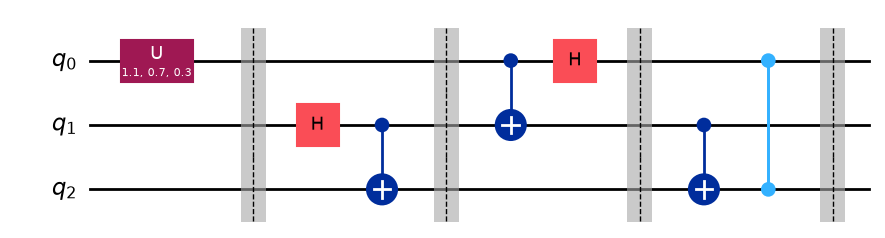

Circuito de teleportación con el estado de Bell: phi-


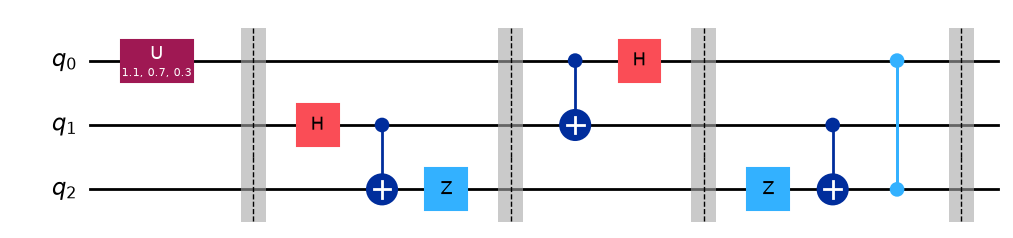

Circuito de teleportación con el estado de Bell: psi+


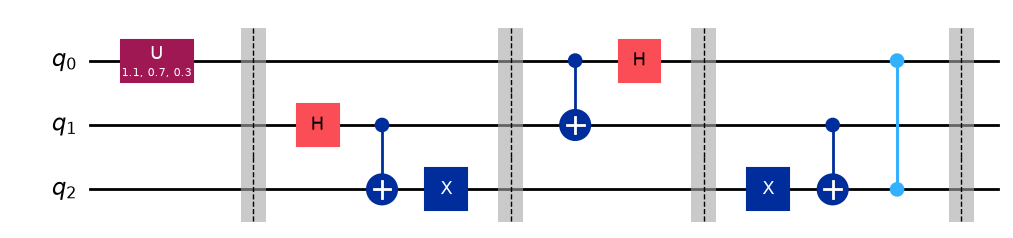

Circuito de teleportación con el estado de Bell: psi-


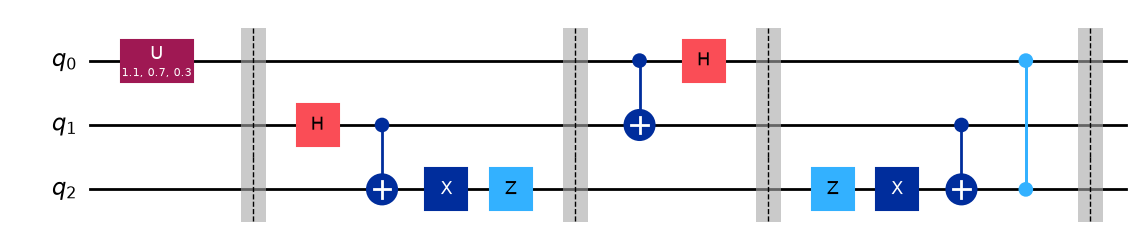

In [4]:
# Llamo a la MISMA función con los cuatro Bell, sin tocarla entre una corrida y otra
nombres_bell = {"phi+": r"$|\Phi^+\rangle$", "phi-": r"$|\Phi^-\rangle$",
                "psi+": r"$|\Psi^+\rangle$", "psi-": r"$|\Psi^-\rangle$"}

for bell in ["phi+", "phi-", "psi+", "psi-"]:
    qc = teleportacion(THETA, PHI, LAM, bell=bell)
    print(f"Circuito de teleportación con el estado de Bell: {bell}")
    display(qc.draw("mpl"))

```
      /\_____/\
     /  o   o  \
    ( ==  ^  == )
     )         (
    (           )
   ( (  )   (  ) )
  (__(__)___(__)__)
```

### 1.c) Simulación y verificación
Simulador empleado: **`BasicSimulator`** de Qiskit (`qiskit.providers.basic_provider`), con 4096 `shots`.

Para cada estado de Bell se compara:
* la distribución de medición del estado original $|\psi\rangle$ (circuito que solo aplica `U` y mide), y
* la distribución de medición del qubit de Bob (`q2`) al finalizar el protocolo.

Además se calcula la fidelidad entre $|\psi\rangle$ y el estado reducido de Bob usando `Statevector`, lo que verifica también las fases (que un histograma en la base computacional no distingue).

Estado original: {'0': 2958, '1': 1138}


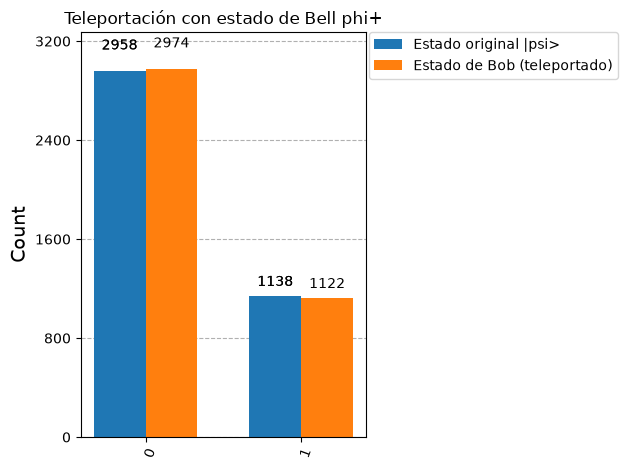

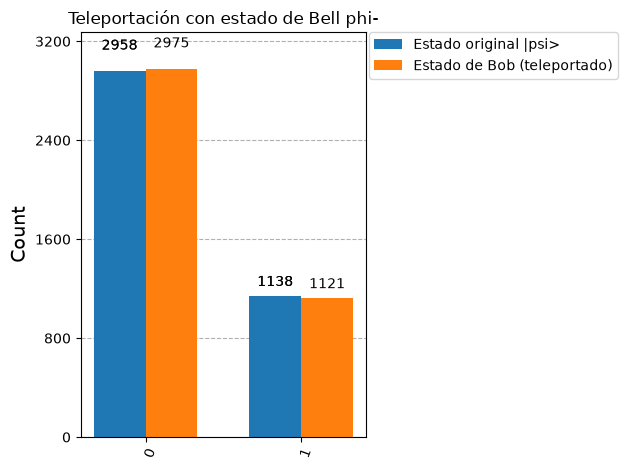

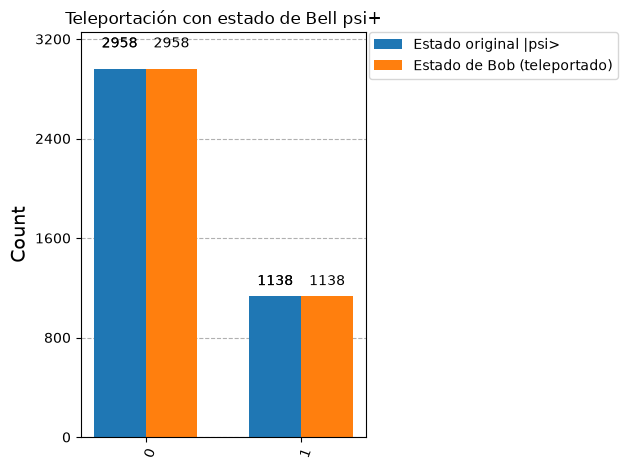

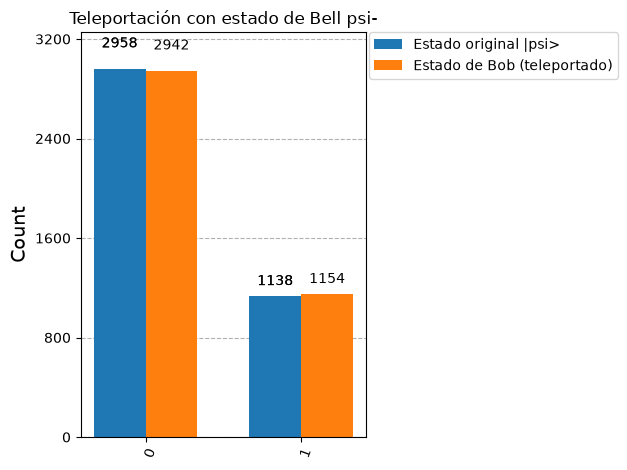

Bell    P(1) orig.    P(1) Bob   Fidelidad   Correcto
phi+        0.2778      0.2739    1.000000   SI
phi-        0.2778      0.2737    1.000000   SI
psi+        0.2778      0.2778    1.000000   SI
psi-        0.2778      0.2817    1.000000   SI


In [5]:
SHOTS = 4096

# Circuito de referencia: solo preparo |psi> y lo mido, para tener con qué comparar
qc_ref = QuantumCircuit(1, 1)
qc_ref.u(THETA, PHI, LAM, 0)
qc_ref.measure(0, 0)
counts_orig = sim.run(transpile(qc_ref, sim), shots=SHOTS).result().get_counts()
print("Estado original:", counts_orig)

resumen = []
for bell in ["phi+", "phi-", "psi+", "psi-"]:
    # Corro el protocolo midiendo solamente a Bob (q2)
    qc_m = teleportacion(THETA, PHI, LAM, bell=bell, medir=True)
    counts_bob = sim.run(transpile(qc_m, sim), shots=SHOTS).result().get_counts()

    # Y aparte checo con el vector de estado qué tan parecido quedó el qubit de Bob a |psi>
    sv = Statevector.from_instruction(teleportacion(THETA, PHI, LAM, bell=bell))
    rho_bob = partial_trace(sv, [0, 1])
    fid = state_fidelity(rho_bob, psi)

    p_orig = counts_orig.get("1", 0) / SHOTS
    p_bob = counts_bob.get("1", 0) / SHOTS
    ok = abs(p_orig - p_bob) < 0.05 and fid > 0.999999
    resumen.append((bell, p_orig, p_bob, fid, ok))

    display(plot_histogram([counts_orig, counts_bob],
                           legend=["Estado original |psi>", "Estado de Bob (teleportado)"],
                           title=f"Teleportación con estado de Bell {bell}"))
    plt.show()

print(f"{'Bell':<6}{'P(1) orig.':>12}{'P(1) Bob':>12}{'Fidelidad':>12}   Correcto")
for bell, po, pb, f, ok in resumen:
    print(f"{bell:<6}{po:>12.4f}{pb:>12.4f}{f:>12.6f}   {'SI' if ok else 'NO'}")

**Conclusión del Ejercicio 1:** para los cuatro estados de Bell las distribuciones del estado original y del recuperado por Bob coinciden (diferencias del orden de la fluctuación estadística de los `shots`) y la fidelidad es 1. Esto confirma que la función generalizada teleporta correctamente $|\psi\rangle$ sin importar qué estado de Bell se comparta.

<a id="2"></a>
```
  ∧,,,∧
 (  ̳• · • ̳)
 /    づ♡
```

# 2. Codificación superdensa

### 2.a) Implementación del protocolo
En la codificación superdensa Alicia envía **dos bits clásicos** `ab` usando un solo qubit de un par entrelazado:

1. Se prepara $|\Phi^+\rangle$ entre `q0` (Alicia) y `q1` (Bob).
2. Alicia codifica el mensaje sobre `q0`: aplica $X$ si el segundo bit es 1 y $Z$ si el primer bit es 1.
3. Bob decodifica con una `CNOT` (control `q0`, objetivo `q1`) y una `H` sobre `q0`.
4. Se miden los dos qubits con asignación fija: `q0 → c1` y `q1 → c0`, de modo que la cadena de resultados de Qiskit (`c1c0`) coincide con el mensaje `ab`.

Circuito de codificación superdensa para el mensaje 00:


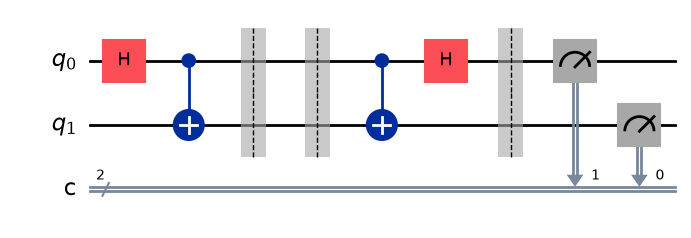

Circuito de codificación superdensa para el mensaje 01:


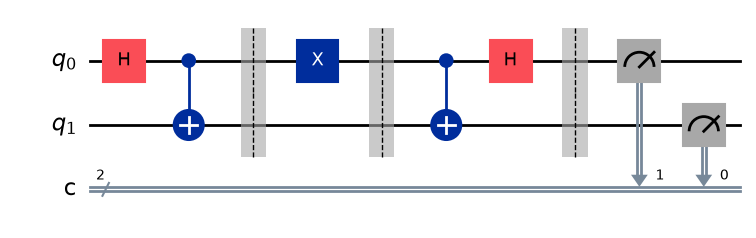

Circuito de codificación superdensa para el mensaje 10:


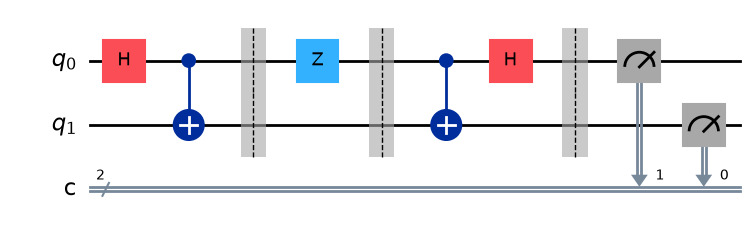

Circuito de codificación superdensa para el mensaje 11:


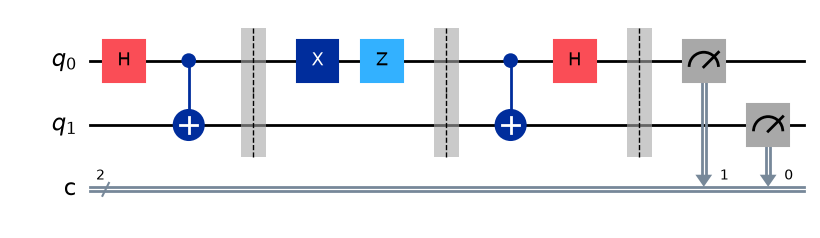

In [6]:
# ==============================================================================
#  /\_/\
# ( o.o )   2. CODIFICACIÓN SUPERDENSA
#  > ^ <
# ==============================================================================
def superdensa(mensaje):
    """Protocolo completo de codificación superdensa para el mensaje '00','01','10' o '11'."""
    if mensaje not in ("00", "01", "10", "11"):
        raise ValueError("El mensaje debe ser '00', '01', '10' o '11'")
    a, b = int(mensaje[0]), int(mensaje[1])

    qc = QuantumCircuit(2, 2)
    # Etapa 1: creo el par entrelazado |Phi+>
    qc.h(0)
    qc.cx(0, 1)
    qc.barrier()
    # Etapa 2: Alicia codifica su mensaje en q0
    if b:
        qc.x(0)
    if a:
        qc.z(0)
    qc.barrier()
    # Etapa 3: Bob decodifica
    qc.cx(0, 1)
    qc.h(0)
    qc.barrier()
    # Etapa 4: mido, siempre con la misma asignación: q0 -> c1 y q1 -> c0
    qc.measure(0, 1)
    qc.measure(1, 0)
    return qc

mensajes = ["00", "01", "10", "11"]
circuitos_sd = {m: superdensa(m) for m in mensajes}
for m, qc in circuitos_sd.items():
    print(f"Circuito de codificación superdensa para el mensaje {m}:")
    display(qc.draw("mpl"))

```
   _._     _,-'""`-._
  (,-.`._,'(       |\`-/|
      `-.-' \ )-`( , o o)
            `-    \`_`"'-
```

### 2.b) Simulación ideal
Simulador: **`BasicSimulator`** de Qiskit, con 1024 `shots` en los cuatro mensajes.

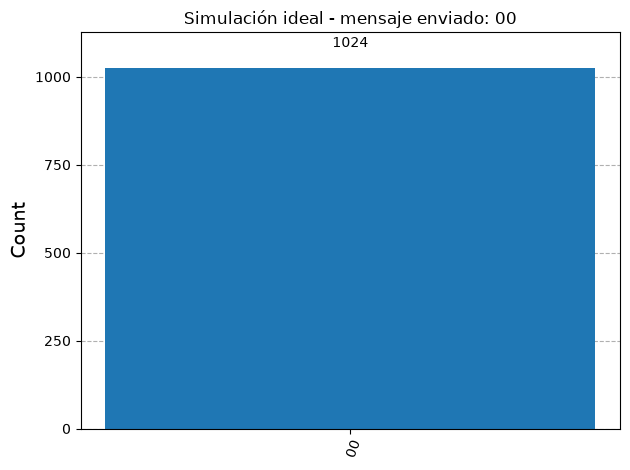

Mensaje enviado: 00 | Bob recupera: 00 | Correcto: True | Conteos: {'00': 1024}


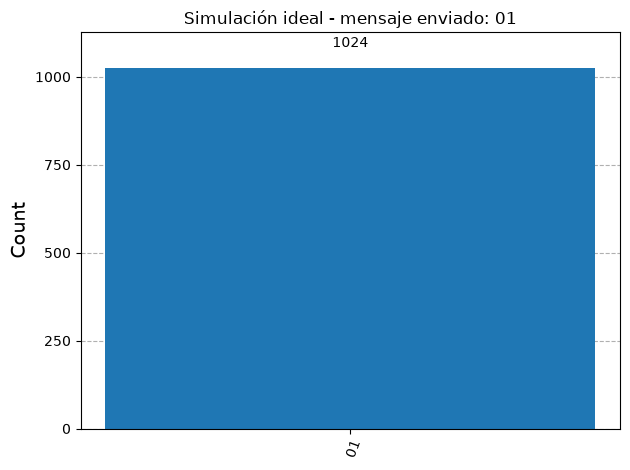

Mensaje enviado: 01 | Bob recupera: 01 | Correcto: True | Conteos: {'01': 1024}


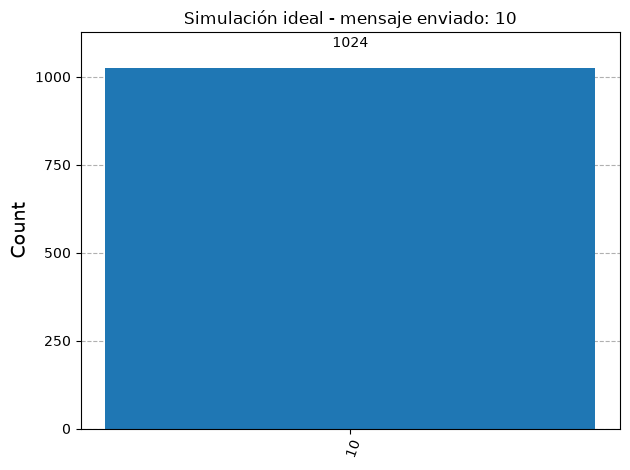

Mensaje enviado: 10 | Bob recupera: 10 | Correcto: True | Conteos: {'10': 1024}


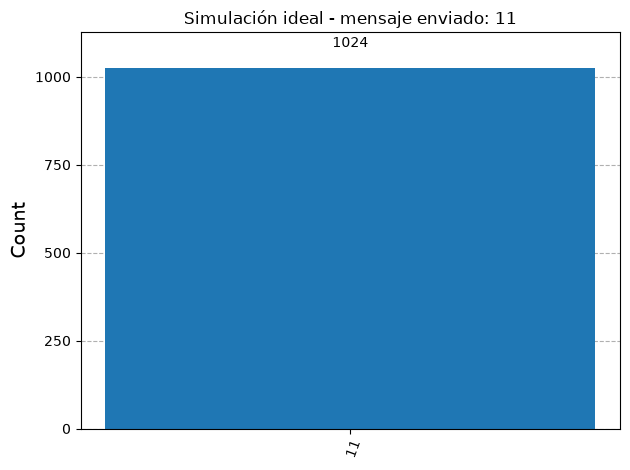

Mensaje enviado: 11 | Bob recupera: 11 | Correcto: True | Conteos: {'11': 1024}


In [7]:
SHOTS_SD = 1024
ideal = {}
for m, qc in circuitos_sd.items():
    ideal[m] = sim.run(transpile(qc, sim), shots=SHOTS_SD).result().get_counts()
    display(plot_histogram(ideal[m], title=f"Simulación ideal - mensaje enviado: {m}"))
    plt.show()
    recuperado = max(ideal[m], key=ideal[m].get)
    print(f"Mensaje enviado: {m} | Bob recupera: {recuperado} | Correcto: {recuperado == m} | Conteos: {ideal[m]}")

```
  /\_/\
 ( ^.^ )
  > ^ <  miau~
```

En la simulación ideal Bob recupera el mensaje con probabilidad 100% en los cuatro casos, ya que el circuito de decodificación convierte cada estado de Bell exactamente en un estado de la base computacional.

```
    |\      _,,,---,,_
    /,`.-'`'    -.  ;-;;,_
   |,4-  ) )-,_. ,\ (  `'-'
  '---''(_/--'  `-'\_)
```

### 2.c) Simulación con ruido (`FakeOsaka`)
Los circuitos se transpilan para `FakeOsaka` con **`optimization_level = 1`** en los cuatro casos (nivel intermedio: optimizaciones ligeras, adecuado para circuitos de 2 qubits) y se ejecutan con los mismos 1024 `shots`. El backend falso incluye el modelo de ruido de la máquina real (errores de compuertas, lectura y relajación).

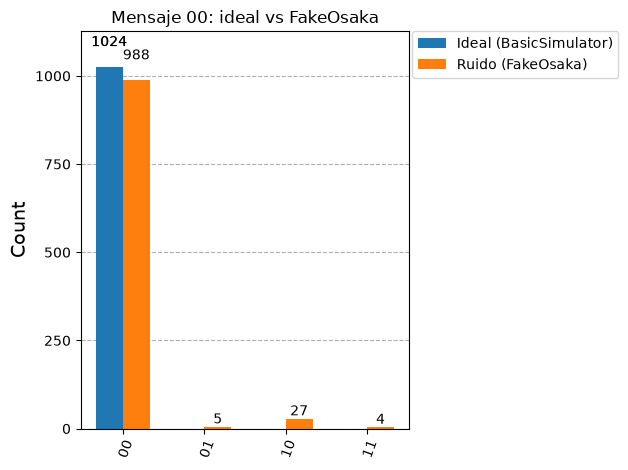

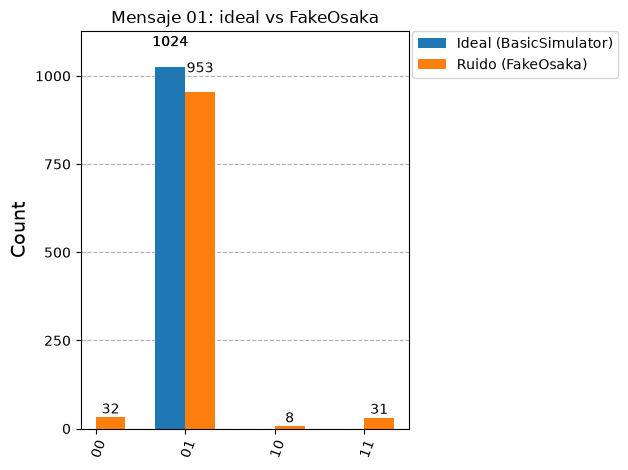

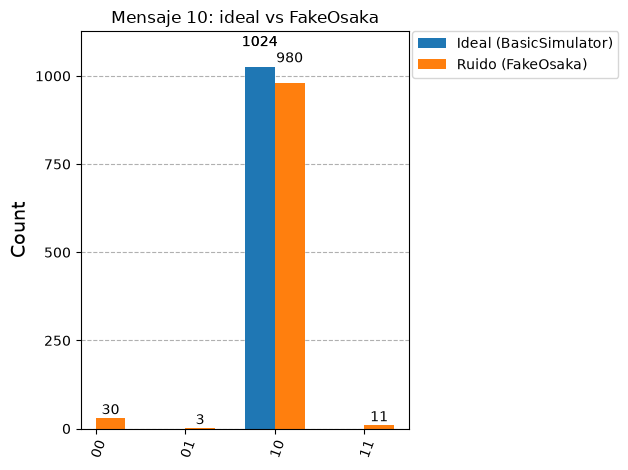

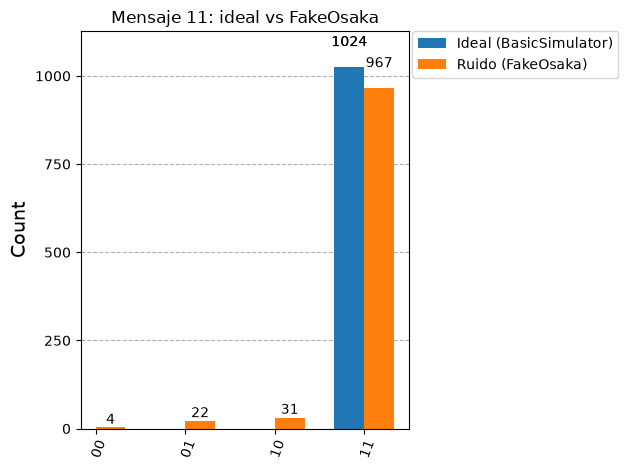

optimization_level = 1 | shots = 1024
Mensaje      % ideal   % FakeOsaka
00            100.00         96.48
01            100.00         93.07
10            100.00         95.70
11            100.00         94.43


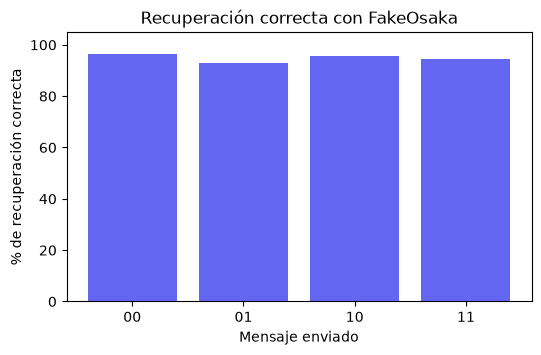

In [8]:
backend = FakeOsaka()
OPT_LEVEL = 1
pm = generate_preset_pass_manager(optimization_level=OPT_LEVEL, backend=backend)

ruido = {}
for m, qc in circuitos_sd.items():
    isa = pm.run(qc)
    ruido[m] = backend.run(isa, shots=SHOTS_SD).result().get_counts()

filas = []
for m in mensajes:
    pct_ideal = ideal[m].get(m, 0) / SHOTS_SD * 100
    pct_ruido = ruido[m].get(m, 0) / SHOTS_SD * 100
    filas.append((m, pct_ideal, pct_ruido))
    display(plot_histogram([ideal[m], ruido[m]], legend=["Ideal (BasicSimulator)", "Ruido (FakeOsaka)"],
                           title=f"Mensaje {m}: ideal vs FakeOsaka"))
    plt.show()

print(f"optimization_level = {OPT_LEVEL} | shots = {SHOTS_SD}")
print(f"{'Mensaje':<10}{'% ideal':>10}{'% FakeOsaka':>14}")
for m, pi, pr in filas:
    print(f"{m:<10}{pi:>10.2f}{pr:>14.2f}")

plt.figure(figsize=(6, 3.5))
plt.bar(mensajes, [f[2] for f in filas], color="#6366F1")
plt.ylim(0, 105)
plt.ylabel("% de recuperación correcta")
plt.xlabel("Mensaje enviado")
plt.title("Recuperación correcta con FakeOsaka")
plt.show()

**Comentario sobre las diferencias:** con ruido, Bob ya no recupera el mensaje el 100% de las veces: aparecen conteos en los otros tres resultados por errores de las compuertas de dos qubits (`CNOT`/`ECR`), de las compuertas de un qubit y, sobre todo, de la lectura. Los porcentajes de los cuatro mensajes son altos (alrededor de 94-95%) y muy parecidos, pero no idénticos: las diferencias provienen del número de compuertas extra que requiere cada codificación ($X$, $Z$ o ambas), de que el error de lectura es asimétrico (medir $|1\rangle$ suele fallar más que medir $|0\rangle$) y de la fluctuación estadística de los `shots`. En esta ejecución el mensaje `11` (que usa ambas compuertas y produce dos unos al medir) obtuvo el porcentaje más bajo; las diferencias entre mensajes son pequeñas frente al efecto global del ruido.

<a id="3"></a>
```
 /\_/\
( o.o )  ¡a trabajar!
 > ^ <
```

# 3. Funciones cuánticas AND y OR

Asignación de qubits: `q0` = entrada $a$, `q1` = entrada $b$ y `q2` = salida (inicia en $|0\rangle$). El `Statevector` de Qiskit se escribe en el orden $|q_2q_1q_0\rangle$.

### 3.a) Función AND
$a\wedge b$ se calcula con una compuerta Toffoli (`ccx`): `q2` se invierte solo si $a=b=1$.

Circuito de la función AND:


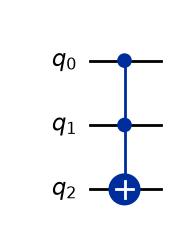

Circuito completo con q0 y q1 en |+> (AND):


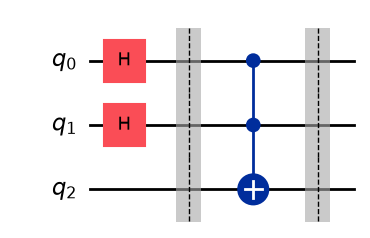

Statevector resultante (AND):


<IPython.core.display.Latex object>

Resultados asociados a cada entrada (AND):
a b   estado |q2 q1 q0>   amplitud    salida
0 0   |000>            0.5000      0
1 0   |001>            0.5000      0
0 1   |010>            0.5000      0
1 1   |111>            0.5000      1


In [9]:
# ==============================================================================
#  /\_/\
# ( o.o )   3. FUNCIONES CUÁNTICAS AND Y OR
#  > ^ <
# ==============================================================================
def funcion_and():
    qc = QuantumCircuit(3, name="AND")
    qc.ccx(0, 1, 2)          # q2 se voltea solo si a y b son 1
    return qc

def funcion_or():
    qc = QuantumCircuit(3, name="OR")
    qc.cx(0, 2)              # copio a en q2
    qc.cx(1, 2)              # ahora q2 guarda a XOR b
    qc.ccx(0, 1, 2)          # le sumo (a AND b) y queda a OR b
    return qc

def analiza_funcion(funcion, titulo):
    f = funcion()
    print(f"Circuito de la función {titulo}:")
    display(f.draw("mpl"))

    qc = QuantumCircuit(3)
    qc.h(0)
    qc.h(1)
    qc.barrier()
    qc.compose(f, inplace=True)
    qc.barrier()
    print(f"Circuito completo con q0 y q1 en |+> ({titulo}):")
    display(qc.draw("mpl"))

    sv = Statevector.from_instruction(qc)
    print(f"Statevector resultante ({titulo}):")
    display(sv.draw("latex"))

    print(f"Resultados asociados a cada entrada ({titulo}):")
    print(f"{'a b':<6}{'estado |q2 q1 q0>':<20}{'amplitud':<12}{'salida'}")
    for i, amp in enumerate(sv.data):
        if abs(amp) > 1e-9:
            etiqueta = format(i, "03b")
            a, b, out = etiqueta[2], etiqueta[1], etiqueta[0]
            print(f"{a} {b:<4}|{etiqueta}>{'':<12}{amp.real:<12.4f}{out}")
    return sv

sv_and = analiza_funcion(funcion_and, "AND")

**Interpretación (AND):** el estado final es una superposición uniforme de cuatro términos de amplitud $1/2$, uno por cada entrada posible:

$$\tfrac12\left(|0\,0\,0\rangle+|0\,0\,1\rangle+|0\,1\,0\rangle+|1\,1\,1\rangle\right)_{q_2q_1q_0}$$

* Entrada $00$ → $|000\rangle$, salida 0.
* Entrada $01$ ($a=1,b=0$) → $|001\rangle$, salida 0.
* Entrada $10$ ($a=0,b=1$) → $|010\rangle$, salida 0.
* Entrada $11$ → $|111\rangle$, salida 1.

**Paralelismo cuántico:** con una sola aplicación de la función sobre $|+\rangle|+\rangle$ (superposición de las cuatro entradas) se evalúan simultáneamente las cuatro combinaciones: cada término de la superposición lleva su entrada junto con la salida correspondiente de la función.

```
  |\__/,|   (`\
  |_ _  |.--.) )
  ( T   )     /
 (((^_(((/(((_/
```

### 3.b) Función OR
Se usa $a\vee b = a\oplus b\oplus(a\wedge b)$: dos `CNOT` calculan $a\oplus b$ en `q2` y una Toffoli agrega el término $a\wedge b$.

Circuito de la función OR:


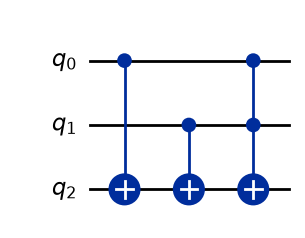

Circuito completo con q0 y q1 en |+> (OR):


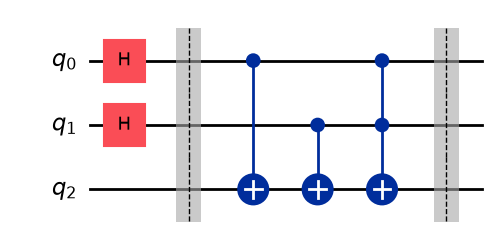

Statevector resultante (OR):


<IPython.core.display.Latex object>

Resultados asociados a cada entrada (OR):
a b   estado |q2 q1 q0>   amplitud    salida
0 0   |000>            0.5000      0
1 0   |101>            0.5000      1
0 1   |110>            0.5000      1
1 1   |111>            0.5000      1


In [10]:
sv_or = analiza_funcion(funcion_or, "OR")

**Interpretación (OR):** el estado final es

$$\tfrac12\left(|0\,0\,0\rangle+|1\,0\,1\rangle+|1\,1\,0\rangle+|1\,1\,1\rangle\right)_{q_2q_1q_0}$$

* Entrada $00$ → $|000\rangle$, salida 0.
* Entrada $01$ ($a=1,b=0$) → $|101\rangle$, salida 1.
* Entrada $10$ ($a=0,b=1$) → $|110\rangle$, salida 1.
* Entrada $11$ → $|111\rangle$, salida 1.

**Paralelismo cuántico:** igual que en AND, una sola ejecución del circuito procesa a la vez las cuatro entradas; la diferencia está únicamente en el valor de `q2` asociado a cada término (aquí es 1 en tres de los cuatro casos). Al medir se obtendría solo uno de ellos al azar, por lo que la ventaja requiere algoritmos que interfieran estos términos.

<a id="4"></a>
```
      /\_____/\
     /  o   o  \
    ( ==  ^  == )
     )         (
    (           )
   ( (  )   (  ) )
  (__(__)___(__)__)
```

# 4. Opcional: Teleportación cuántica con PennyLane

Se implementa el protocolo con tres wires: `0` contiene $|\psi\rangle$, `1` es el qubit de Alicia y `2` el de Bob. El par $|\Phi^+\rangle$ se crea entre los wires 1 y 2. Alicia mide sus dos qubits con `qml.measure` y Bob corrige con `qml.cond` ($X$ según el wire 1 y $Z$ según el wire 0).

Para verificar que Bob recupera $|\psi\rangle$ se comparan los valores esperados $\langle X\rangle$, $\langle Y\rangle$, $\langle Z\rangle$ del wire 2 con los del estado original (mismas coordenadas en la esfera de Bloch).

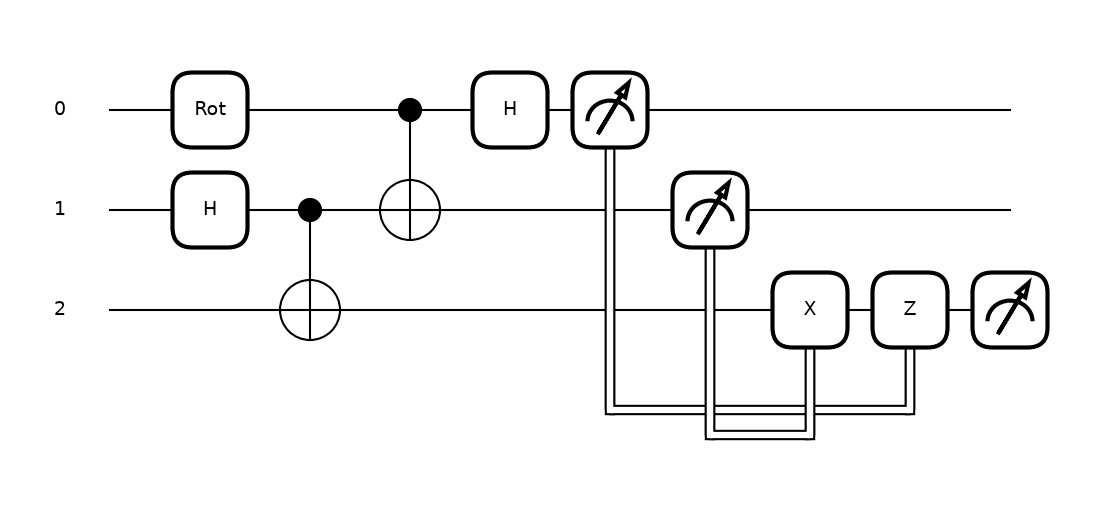

Vector de Bloch del estado original |psi> : [0.681633 0.574132 0.453596]
Vector de Bloch de q2 (Bob) tras el protocolo: [0.681633 0.574132 0.453596]
¿q2 recupera |psi>? True


In [11]:
# ==============================================================================
#  /\_/\
# ( o.o )   4. TELEPORTACIÓN CON PENNYLANE
#  > ^ <
# ==============================================================================
import pennylane as qml

dev = qml.device("default.qubit", wires=3)

def prepara_psi(wire):
    # Es el mismo |psi> de antes (distinto de |0>): U(theta, phi, lam) = Rz(phi) Ry(theta) Rz(lam)
    qml.Rot(LAM_PL, THETA_PL, PHI_PL, wires=wire)

THETA_PL, PHI_PL, LAM_PL = 1.1, 0.7, 0.3

@qml.qnode(dev)
def teleporta_pl():
    # q0 trae el estado que quiero teleportar
    prepara_psi(0)
    # Par de Bell |Phi+> entre q1 (Alicia) y q2 (Bob)
    qml.Hadamard(wires=1)
    qml.CNOT(wires=[1, 2])
    # Alicia hace lo suyo y mide sus dos qubits
    qml.CNOT(wires=[0, 1])
    qml.Hadamard(wires=0)
    m0 = qml.measure(0)
    m1 = qml.measure(1)
    # Bob corrige su qubit según lo que midió Alicia
    qml.cond(m1, qml.PauliX)(wires=2)
    qml.cond(m0, qml.PauliZ)(wires=2)
    return [qml.expval(qml.PauliX(2)), qml.expval(qml.PauliY(2)), qml.expval(qml.PauliZ(2))]

@qml.qnode(dev)
def referencia_pl():
    prepara_psi(0)
    return [qml.expval(qml.PauliX(0)), qml.expval(qml.PauliY(0)), qml.expval(qml.PauliZ(0))]

fig, ax = qml.draw_mpl(teleporta_pl)()
plt.show()

bloch_bob = np.array(teleporta_pl())
bloch_psi = np.array(referencia_pl())
print("Vector de Bloch del estado original |psi> :", np.round(bloch_psi, 6))
print("Vector de Bloch de q2 (Bob) tras el protocolo:", np.round(bloch_bob, 6))
print("¿q2 recupera |psi>?", np.allclose(bloch_bob, bloch_psi, atol=1e-8))

**Conclusión:** el vector de Bloch del qubit de Bob coincide con el del estado original, por lo que `q2` recupera $|\psi\rangle$ y el protocolo de teleportación en PennyLane funciona correctamente.